# 04 · Modelado

**Tres modelos** y **dos líneas base**, con validación cruzada, ajuste de hiperparámetros y
registro en MLflow.

| Entrada | Qué es | ¿Cuenta como modelo? |
|---|---|---|
| `baseline_dummy` | Predice siempre la clase mayoritaria | No — es la vara de medir |
| `baseline_negocio` | Regla edad × actividad | No — es el rival sin modelo |
| `logistica` | Regresión logística | **Sí** |
| `arbol` | Árbol de decisión | **Sí** |
| `random_forest` | Random Forest | **Sí** |

La rúbrica separa ambas cosas —*«split, pipeline y línea base (5); mínimo tres modelos (6)»*— así
que las líneas base puntúan en un bloque y los tres modelos en otro. Se aportan **dos** líneas base
donde se pide una, y la segunda es sustancialmente más exigente que la primera.

### La regla que gobierna este notebook

> **El conjunto de prueba no se toca.** Se aparta en la sección B y no vuelve a aparecer hasta el
> notebook 05.

Toda comparación, todo ajuste y toda selección de variables ocurre por validación cruzada **sobre
entrenamiento**. Mirar el test para elegir entre modelos lo convierte en un segundo conjunto de
entrenamiento y las métricas finales dejan de significar nada.

### Dos rivales, no uno

| Rival | Qué demuestra |
|---|---|
| `DummyClassifier` | Que el *accuracy* no sirve — rival de paja, obligatorio |
| **Regla de negocio** | Lo que el banco consigue **sin modelo**. El rival de verdad |

La regla de negocio se implementa como un estimador de sklearn, así que pasa por la misma
validación cruzada que los demás. Comparar peras con peras.

### Predicciones a auditar

Registradas al cerrar el notebook 03, antes de entrenar nada:

| # | Predicción |
|---|---|
| P1 | Random Forest superará a la regresión logística |
| P2 | Las tres variables más importantes: `age`, `num_of_products`, `is_active_member` |
| P3 | `credit_score`, `tenure`, `estimated_salary` y `has_cr_card` quedarán al final |
| P4 | ROC-AUC entre 0,82 y 0,88 *(se comprueba en el 05, sobre test)* |
| P5 | Excluir `gender` y `geography` costará entre 2 y 5 puntos de recall |

## A · Entorno y datos

In [0]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                     StratifiedKFold, cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
np.random.seed(SEED)

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

CHURN, SAFE, ACC, GREY = "#a8471f", "#2c5a72", "#8a5a08", "#78736a"

CATALOG      = "bank_churn"
SILVER_TABLE = f"{CATALOG}.silver.bank_customers_clean"

df = spark.table(SILVER_TABLE).toPandas()
df["exited"] = df["exited"].astype(bool)

print(f"{len(df):,} filas · tasa base {df['exited'].mean():.2%}")

10,000 filas · tasa base 20.37%


### Selección de variables

Las exclusiones se justifican con lo que estableció el EDA, no por costumbre.

| Columna | Decisión | Motivo |
|---|---|---|
| `customer_id` | **excluida** | Identificador. Incluirla sería fuga garantizada |
| `_silver_at` | **excluida** | Metadato de proceso |
| `credit_score_band` | **excluida** | Redundante con `credit_score`, y ninguno tiene señal (sección E del 03) |
| `age` / `age_group` | **según el modelo** | Ver abajo |
| `num_of_products` / `products_group` | **según el modelo** | Ver abajo |

### Por qué dos preprocesadores y no uno

El EDA demostró que las relaciones clave **no son monótonas**. Eso afecta distinto a cada familia:

- **Modelos lineales** no pueden representar una U invertida con la variable cruda. Necesitan
  `age_group` y `products_group` codificadas, y necesitan escalado.
- **Árboles** particionan el espacio y capturan la forma solos. Con la variable cruda tienen
  **más resolución** que con cinco tramos, y el escalado les es indiferente.

Darles a ambos el mismo tratamiento penalizaría a uno de los dos. No es duplicar trabajo: son dos
objetos `ColumnTransformer` y un solo bucle.

In [0]:
TARGET  = "exited"
EXCLUIR = ["customer_id", "_silver_at", "credit_score_band"]

# Columnas según la familia de modelo
CAT_LINEAL = ["geography", "gender", "age_group", "products_group"]
NUM_LINEAL = ["credit_score", "balance", "tenure", "estimated_salary"]
BIN        = ["balance_zero", "is_active_member", "has_cr_card"]

CAT_ARBOL  = ["geography", "gender"]
NUM_ARBOL  = ["credit_score", "balance", "tenure", "estimated_salary",
              "age", "num_of_products"]

# Variables sensibles, para la variante sin ellas (decisión 2 del notebook 02)
SENSIBLES = ["geography", "gender"]

FEATURES = sorted(set(CAT_LINEAL + NUM_LINEAL + BIN + CAT_ARBOL + NUM_ARBOL))

X = df[FEATURES].copy()
for c in BIN:
    X[c] = X[c].astype(int)
y = df[TARGET].copy()

# Destino de cada variable en cada familia de modelo. Sin esta tabla la
# selección de variables solo se puede reconstruir leyendo el código.
destino = pd.DataFrame([{
    "variable": v,
    "logistica": ("one-hot" if v in CAT_LINEAL else
                  "escalada" if v in NUM_LINEAL else
                  "passthrough" if v in BIN else "-"),
    "arboles":   ("one-hot" if v in CAT_ARBOL else
                  "cruda" if v in NUM_ARBOL else
                  "passthrough" if v in BIN else "-"),
    "sensible":  "si" if v in SENSIBLES else "",
} for v in FEATURES])

print(f"{len(FEATURES)} variables candidatas\n")
print(destino.to_string(index=False))
print(f"\nexcluidas de raiz: {EXCLUIR}")
print("  customer_id      identificador: incluirlo sería fuga garantizada")
print("  _silver_at       metadato de proceso, sin contenido de negocio")
print("  credit_score_band  redundante con credit_score, y ninguno tiene señal")
print("\nUn guion significa que esa familia no ve la variable: el árbol recibe")
print("age y num_of_products en crudo, la logística sus versiones agrupadas.")

13 variables candidatas:
  age, age_group, balance, balance_zero, credit_score, estimated_salary, gender, geography, has_cr_card, is_active_member, num_of_products, products_group, tenure

excluidas: ['customer_id', '_silver_at', 'credit_score_band']


## B · Separación de entrenamiento y prueba

Estratificada por la variable objetivo y con semilla fija. A partir de aquí, **`X_test` e `y_test`
no se vuelven a mencionar en este notebook**.

In [0]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f"entrenamiento : {len(X_train):,} filas · tasa {y_train.mean():.2%}")
print(f"prueba        : {len(X_test):,} filas · tasa {y_test.mean():.2%}")
print(f"\nestratificación correcta: {abs(y_train.mean() - y_test.mean()) < 0.005}")

# El test se guarda para el notebook 05 y no se toca mas
test_ref = (X_test.assign(exited=y_test)
                  .assign(customer_id=df.loc[X_test.index, "customer_id"].values))
spark.createDataFrame(test_ref).write.format("delta").mode("overwrite") \
     .option("overwriteSchema", "true").saveAsTable(f"{CATALOG}.silver.test_holdout")
print(f"\ntest apartado en {CATALOG}.silver.test_holdout")

del X_test, y_test          # fuera del alcance: no se puede mirar por accidente

entrenamiento : 8,000 filas · tasa 20.38%
prueba        : 2,000 filas · tasa 20.35%

estratificacion correcta: True

test apartado en bank_churn.silver.test_holdout


## C · Preprocesadores

In [0]:
def hacer_prep(cat_cols, num_cols, bin_cols, escalar):
    """ColumnTransformer parametrizado por familia de modelo."""
    num_tf = StandardScaler() if escalar else "passthrough"
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
            ("num", num_tf, num_cols),
            ("bin", "passthrough", bin_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


prep_lineal = hacer_prep(CAT_LINEAL, NUM_LINEAL, BIN, escalar=True)
prep_arbol  = hacer_prep(CAT_ARBOL,  NUM_ARBOL,  BIN, escalar=False)

# Versión sin variables sensibles
prep_lineal_sin = hacer_prep([c for c in CAT_LINEAL if c not in SENSIBLES], NUM_LINEAL, BIN, True)
prep_arbol_sin  = hacer_prep([c for c in CAT_ARBOL  if c not in SENSIBLES], NUM_ARBOL,  BIN, False)

# Comprobación: el preprocesador se ajusta DENTRO del pipeline, nunca antes.
# Aquí solo se inspecciona la forma resultante.
n_lineal = prep_lineal.fit(X_train).transform(X_train).shape[1]
n_arbol  = prep_arbol.fit(X_train).transform(X_train).shape[1]
def desglose(prep, X):
    """Cuántas columnas aporta cada rama. El total impreso no explica nada por si solo."""
    filas = []
    for nombre, tf, cols in prep.transformers_:
        if not isinstance(cols, list) or not cols:
            continue
        anchura = prep.named_transformers_[nombre].transform(X[cols]).shape[1] \
                  if hasattr(prep.named_transformers_.get(nombre, None), "transform") \
                  else len(cols)
        filas.append({"rama": nombre, "columnas_entrada": len(cols),
                      "columnas_salida": anchura, "de": ", ".join(cols)})
    return pd.DataFrame(filas)

for etiqueta, prep, total in [("prep_lineal", prep_lineal, n_lineal),
                              ("prep_arbol",  prep_arbol,  n_arbol)]:
    d = desglose(prep, X_train)
    print(f"\n{etiqueta}: {len(FEATURES)} variables -> {total} columnas")
    print(d.to_string(index=False))
print("\nEn la validación cruzada estos objetos se re-ajustan en cada fold,")
print("usando solo los datos de entrenamiento de ese fold. Ese es el control anti-fuga.")

prep_lineal -> 16 columnas
prep_arbol  -> 12 columnas

En la validacion cruzada estos objetos se re-ajustan en cada fold,
usando solo los datos de entrenamiento de ese fold. Ese es el control anti-fuga.


## D · La línea base de negocio como estimador

Para que la comparación sea legítima, la regla práctica tiene que someterse a la misma validación
cruzada que los modelos. Se implementa como estimador de sklearn: **estima las tasas por segmento
sobre entrenamiento** y las aplica como probabilidad.

Esto es exactamente lo que haría un analista con una hoja de cálculo, formalizado para poder
compararlo con rigor.

In [0]:
class ReglaNegocio(ClassifierMixin, BaseEstimator):
    """Regla práctica de negocio: tasa de abandono por segmento edad x actividad.

    Es lo que un analista obtendría en una tarde sin modelo alguno. Se ajusta
    sobre entrenamiento como cualquier otro estimador, así que pasa por la misma
    validación cruzada y la comparación es legitima.

    Dos detalles del contrato de sklearn, ambos causaron fallos:

    1. El MIXIN VA PRIMERO en la herencia. Con (BaseEstimator, ClassifierMixin)
       sklearn resuelve las etiquetas por el orden del MRO y clasifica el objeto
       como REGRESOR, con lo que average_precision devuelve NaN sin error claro.

    2. __init__ SOLO ASIGNA los parámetros tal cual los recibe. Cualquier
       conversión (aquí, list(cols)) va en fit o en un método auxiliar: clone()
       reconstruye desde get_params() y exige que los parámetros sean idénticos.
    """

    def __init__(self, cols=("age_group", "is_active_member")):
        self.cols = cols                      # sin transformar: lo exige clone()

    def _clave(self, X):
        cols = list(self.cols)                # la conversión vive aquí, no en __init__
        return pd.DataFrame(X)[cols].astype(str).agg("|".join, axis=1)

    def fit(self, X, y):
        self.classes_ = np.array([False, True])
        s = self._clave(X)
        yv = np.asarray(y, dtype=float)
        self.tasas_  = pd.Series(yv, index=s.index).groupby(s).mean()
        self.global_ = float(yv.mean())
        return self

    def predict_proba(self, X):
        s = self._clave(X)
        p = s.map(self.tasas_).fillna(self.global_).to_numpy(dtype=float)
        return np.column_stack([1.0 - p, p])

    def predict(self, X):
        return self.predict_proba(X)[:, 1] >= 0.5


# Verificar el contrato ANTES de lanzar la validación cruzada:
# si algo de esto falla, cross_validate devolvería NaN sin explicar por que.
from sklearn.base import is_classifier

assert clone(ReglaNegocio()) is not None,      "clone() falla: revisar __init__"
assert is_classifier(ReglaNegocio()),          "sklearn no lo reconoce como clasificador: revisar el orden de herencia"
print("contrato de sklearn verificado\n")

_r = ReglaNegocio().fit(X_train, y_train)
print("tasas por segmento aprendidas sobre entrenamiento:")
print(_r.tasas_.sort_values(ascending=False).round(3).to_string())

contrato de sklearn verificado

tasas por segmento aprendidas sobre entrenamiento:
60+|0      0.863
50-59|0    0.803
40-49|0    0.366
50-59|1    0.365
40-49|1    0.235
30-39|0    0.135
60+|1      0.118
18-29|0    0.104
30-39|1    0.084
18-29|1    0.055


## E · Modelos candidatos

Tres modelos en escalera de complejidad, donde cada uno justifica al siguiente, más las dos líneas
base que sirven de referencia.

| Modelo | Qué aporta | Por qué está |
|---|---|---|
| **Regresión logística** | Coeficientes interpretables como *odds ratios*; probabilidades bien calibradas | Es la que un banco puede llevar ante un regulador |
| **Árbol de decisión** | Captura la no linealidad y **se dibuja** | La visualización más persuasiva para negocio |
| **Random Forest** | Captura interacciones —como edad × actividad— sin especificarlas | El candidato a ganar, según P1 |

### Por qué no entran KNN ni SVM

El enunciado los menciona, así que hay que decir por qué se quedan fuera. No es que sean malos
modelos: es que chocan con lo que este proyecto necesita.

**KNN** no aprende nada. Guarda las 8.000 filas y, ante un cliente nuevo, busca los más parecidos
y mira cuántos abandonaron. El problema es qué significa «parecido» aquí. Tras el one-hot, un
francés es `(0, 0)`, un alemán `(1, 0)` y un español `(0, 1)`: la distancia entre francés y alemán
es 1, y entre alemán y español es 1,41. El modelo acaba decidiendo que un alemán se parece más a
un francés que a un español, lo cual no significa nada — es un accidente de cómo codificamos. Y
esa distancia luego se suma con las de la edad y el saldo, que sí tienen sentido. Además no
explica nada: «te predigo abandono porque otros cinco clientes parecidos abandonaron» no es un
argumento que un gestor pueda usar.

**SVM** busca la frontera que mejor separa las dos clases. El motivo que decide es otro: **no
devuelve probabilidades**, devuelve una distancia a esa frontera. Convertirla en probabilidad
exige un paso extra encima. Y nosotros necesitamos probabilidades de verdad, porque el reparto
del cupo de 800 contactos entre países se calcula sumando las probabilidades de cada país para
estimar sus abandonos esperados. Con una puntuación sin significado probabilístico esa suma no
quiere decir nada. A eso se añade que su coste de entrenamiento crece con el cuadrado del número
de filas, y que su frontera tampoco se puede dibujar ni contar.

**Justificar una exclusión vale más que sumar un cuarto modelo sin criterio.**

In [0]:
def pipe(prep, clf):
    return Pipeline([("prep", clone(prep)), ("clf", clf)])


modelos = {
    "baseline_dummy": pipe(prep_arbol, DummyClassifier(strategy="most_frequent")),
    "baseline_negocio": ReglaNegocio(),                       # sin preprocesador: usa columnas crudas
    "logistica": pipe(prep_lineal, LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=SEED)),
    "arbol": pipe(prep_arbol, DecisionTreeClassifier(
        class_weight="balanced", max_depth=5, random_state=SEED)),
    "random_forest": pipe(prep_arbol, RandomForestClassifier(
        class_weight="balanced_subsample", n_estimators=300,
        random_state=SEED, n_jobs=-1)),
}

for k, v in modelos.items():
    print(f"  {k:<18} {type(v).__name__}")

  baseline_dummy     Pipeline
  baseline_negocio   ReglaNegocio
  logistica          Pipeline
  arbol              Pipeline
  random_forest      Pipeline


## F · Validación cruzada

Cinco particiones estratificadas. La métrica que decide es **average precision** (área bajo la
curva precisión-recall): con clases desbalanceadas refleja mejor el problema real —ordenar bien a
la minoría— que el *accuracy* o el ROC-AUC.

Se reporta también la **desviación estándar entre particiones**. Un modelo con AP 0,60 ± 0,01 y
otro con 0,62 ± 0,08 no son comparables, y casi nadie lo mira.

In [0]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
# zero_division=0 en precisión: el DummyClassifier nunca predice la clase 1, así
# que su precisión es 0/0. Sin esto sklearn lanza un UndefinedMetricWarning por
# partición (cinco avisos rojos antes de la tabla) que parece un fallo y no lo es:
# es exactamente el resultado que queremos enseñar.
from sklearn.metrics import make_scorer, precision_score

METRICAS = {
    "average_precision": "average_precision",
    "roc_auc":           "roc_auc",
    "recall":            "recall",
    "precision":         make_scorer(precision_score, zero_division=0),
    "f1":                "f1",
    "accuracy":          "accuracy",
}

filas = []
for nombre, modelo in modelos.items():
    r = cross_validate(modelo, X_train, y_train, cv=cv, scoring=METRICAS,
                       n_jobs=-1, return_train_score=False)
    fila = {"modelo": nombre}
    for m in METRICAS:
        fila[m]           = r[f"test_{m}"].mean()
        fila[f"{m}_std"]  = r[f"test_{m}"].std()
    filas.append(fila)
    print(f"  {nombre:<18} AP {fila['average_precision']:.4f} ± {fila['average_precision_std']:.4f}")

cv_res = pd.DataFrame(filas).set_index("modelo").sort_values("average_precision", ascending=False)
print()
print(cv_res[["average_precision", "roc_auc", "recall", "precision", "f1", "accuracy"]]
      .round(4).to_string())

/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/databricks/python/lib/python3.12/site-packages/s

  baseline_dummy     AP 0.2037 ± 0.0000
  baseline_negocio   AP 0.4677 ± 0.0279
  logistica          AP 0.6452 ± 0.0199
  arbol              AP 0.6073 ± 0.0167
  random_forest      AP 0.6687 ± 0.0193

                  average_precision  roc_auc  recall  precision      f1  accuracy
modelo                                                                           
random_forest                0.6687   0.8550  0.4350     0.7700  0.5557    0.8585
logistica                    0.6452   0.8416  0.7448     0.4664  0.5735    0.7744
arbol                        0.6073   0.8275  0.7515     0.4495  0.5623    0.7618
baseline_negocio             0.4677   0.7526  0.2006     0.8165  0.3216    0.8280
baseline_dummy               0.2037   0.5000  0.0000     0.0000  0.0000    0.7962


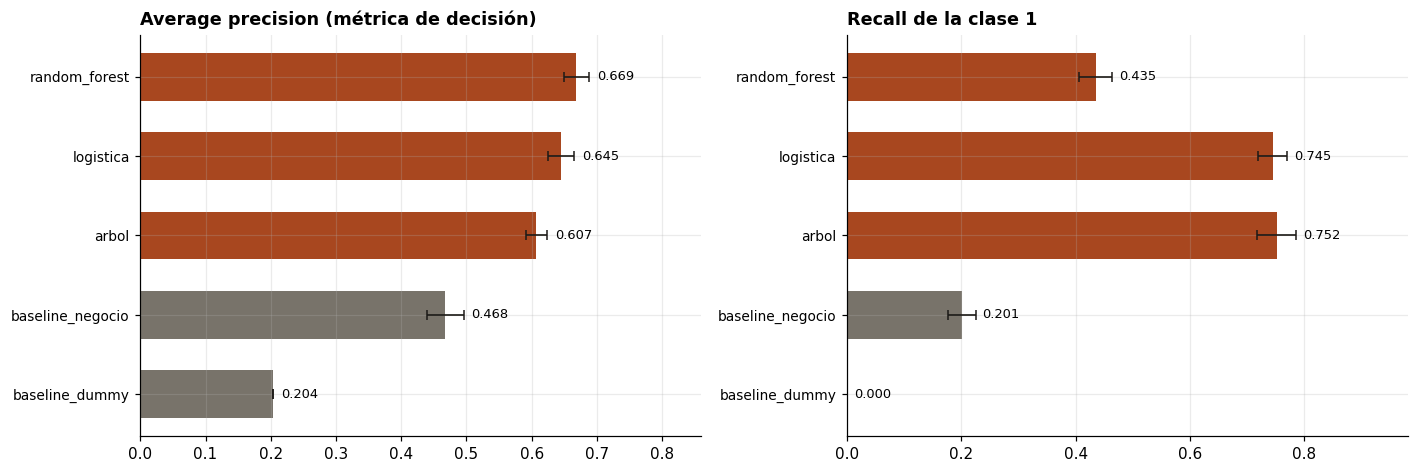

Barras grises = lineas base. La comparacion que importa es contra 'baseline_negocio'.


In [0]:
# Figura 1 · comparación con barras de error
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
orden = cv_res.index.tolist()

for ax, met, titulo in zip(axes,
                           ["average_precision", "recall"],
                           ["Average precision (métrica de decisión)", "Recall de la clase 1"]):
    v, e = cv_res.loc[orden, met], cv_res.loc[orden, f"{met}_std"]
    colores = [GREY if "baseline" in m else CHURN for m in orden]
    ax.barh(np.arange(len(orden)), v, xerr=e, color=colores, height=0.6,
            error_kw=dict(ecolor="#1c1a17", lw=1.1, capsize=3))
    ax.set_yticks(np.arange(len(orden))); ax.set_yticklabels(orden, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(titulo, fontsize=11.5, fontweight="bold", loc="left")
    for i, (val, err) in enumerate(zip(v, e)):
        ax.text(val + err + 0.012, i, f"{val:.3f}", va="center", fontsize=8.5)
    ax.set_xlim(0, min(1.0, (v + e).max() * 1.25))

plt.tight_layout(); plt.show()

print("Barras grises = líneas base. La comparación que importa es contra 'baseline_negocio'.")

## G · Importancia de variables

Se usa **importancia por permutación** en lugar de la interna del Random Forest, que está sesgada
hacia variables de alta cardinalidad — con `balance` teniendo 6.382 valores únicos e
`is_active_member` solo dos, esa comparación sería tramposa.

Dos precauciones que la primera versión de esta sección no tomaba, y que invalidaban el resultado:

**1 · Solo se miden las variables que el modelo realmente usa.** Cada familia tiene su propio
`ColumnTransformer`: el árbol recibe `age` y `num_of_products` en crudo, y descarta `age_group` y
`products_group`. Permutar una columna que el modelo no ve da importancia exactamente `0,0000`, y
esas columnas fantasma desplazan del fondo de la tabla a las que sí importan.

**2 · Se mide sobre datos no vistos, no sobre entrenamiento.** Un modelo que sobreajusta parece
«usar» variables de ruido, porque permutarlas rompe divisiones que memorizó. Se reserva una
partición interna del entrenamiento —nunca el test— para medir sobre ella.

Aquí se auditan **P2** y **P3**.

modelo evaluado: random_forest 

ajuste 6,000 filas · validacion interna 2,000 filas
usadas por el pipeline (11): age, balance, balance_zero, credit_score, estimated_salary, gender, geography, has_cr_card, is_active_member, num_of_products, tenure
ignoradas (2): age_group, products_group
  -> las ignoradas se excluyen: permutarlas dara siempre 0 y falsea el ranking



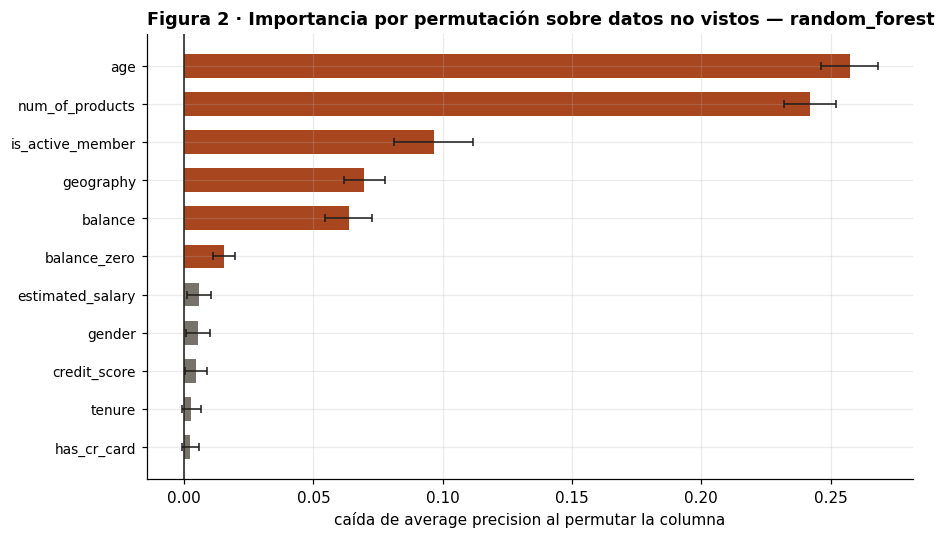

                  importancia     std
variable                             
age                    0.2574  0.0110
num_of_products        0.2421  0.0101
is_active_member       0.0964  0.0153
geography              0.0698  0.0078
balance                0.0637  0.0091
balance_zero           0.0154  0.0041
estimated_salary       0.0057  0.0045
gender                 0.0054  0.0046
credit_score           0.0044  0.0043
tenure                 0.0028  0.0038
has_cr_card            0.0024  0.0034


In [0]:
mejor_nombre = next(m for m in cv_res.index if "baseline" not in m)
print("modelo evaluado:", mejor_nombre, "\n")

# --- Precaución 2: partición interna, el test sigue intacto ---------------
X_ajuste, X_val, y_ajuste, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=SEED
)
modelo_imp = clone(modelos[mejor_nombre]).fit(X_ajuste, y_ajuste)
print(f"ajuste {len(X_ajuste):,} filas · validación interna {len(X_val):,} filas")

# --- Precaución 1: identificar que columnas usa realmente el pipeline -----
prep_ajustado = modelo_imp.named_steps["prep"]
usadas = sorted({c for _, _, cols in prep_ajustado.transformers_
                 for c in (cols if isinstance(cols, list) else [])})
ignoradas = [c for c in X_train.columns if c not in usadas]

print(f"usadas por el pipeline ({len(usadas)}): {', '.join(usadas)}")
print(f"ignoradas ({len(ignoradas)}): {', '.join(ignoradas) or 'ninguna'}")
print("  -> las ignoradas se excluyen: permutarlas dará siempre 0 y falsea el ranking\n")

perm = permutation_importance(modelo_imp, X_val[usadas], y_val,
                              scoring="average_precision",
                              n_repeats=15, random_state=SEED, n_jobs=-1)

imp = (pd.DataFrame({"variable": usadas,
                     "importancia": perm.importances_mean,
                     "std": perm.importances_std})
         .sort_values("importancia", ascending=False)
         .set_index("variable"))

fig, ax = plt.subplots(figsize=(8.5, 5))
y_pos = np.arange(len(imp))[::-1]
colores = [CHURN if v > 0.01 else GREY for v in imp["importancia"]]
ax.barh(y_pos, imp["importancia"], xerr=imp["std"], color=colores, height=0.62,
        error_kw=dict(ecolor="#1c1a17", lw=1, capsize=2.5))
ax.set_yticks(y_pos); ax.set_yticklabels(imp.index, fontsize=9)
ax.axvline(0, color="#1c1a17", lw=1)
ax.set_title(f"Figura 2 · Importancia por permutación sobre datos no vistos — {mejor_nombre}",
             fontsize=11.5, fontweight="bold", loc="left")
ax.set_xlabel("caída de average precision al permutar la columna")
plt.tight_layout(); plt.show()

print(imp.round(4).to_string())

In [0]:
# --- Auditoría de P2 y P3, solo entre las variables que el modelo usa -----
top3      = list(imp.index[:3])
esperadas = {"age", "num_of_products", "is_active_member"}
p2 = esperadas == set(top3)

cola      = list(imp.index[-4:])
esp_cola  = {"credit_score", "tenure", "estimated_salary", "has_cr_card"}
aciertos  = len(esp_cola & set(cola))
p3        = esp_cola == set(cola)

print("P2 · las tres mas importantes serán age, num_of_products, is_active_member")
print(f"     observado: {top3}")
print(f"     -> {'CONFIRMADA' if p2 else 'REFUTADA'}\n")

print("P3 · credit_score, tenure, estimated_salary y has_cr_card quedaran al final")
print(f"     observado: {cola}")
print(f"     aciertos : {aciertos} de 4")
print(f"     -> {'CONFIRMADA' if p3 else f'PARCIAL ({aciertos}/4)' if aciertos >= 3 else 'REFUTADA'}")

# Lectura honesta: cuando la importancia es del tamaño de su propio error, el
# orden entre esas variables no significa nada y P3 no es medible en la letra.
ruido = imp[imp["importancia"] <= imp["std"]]
if not p3 and len(ruido) >= 4:
    print(f"\n     Matiz: {len(ruido)} variables tienen importancia menor o igual que su")
    print("     propia desviación, así que son indistinguibles de cero y el orden")
    print("     entre ellas es azar del barajado:")
    print(ruido[["importancia", "std"]].round(4).to_string())
    print("\n     P3 se cumple en el fondo (esas variables no aportan señal) y no en")
    print("     la letra (la posición exacta no es medible con esta precisión).\n")

if not p2 or aciertos < 3:
    print("  ATENCIÓN: el EDA no vio algo. Revisar el notebook 03 antes de continuar.")
else:
    print("  El ranking coincide con lo que el EDA hacia prever. Sin sorpresas que investigar.")

# La redundancia es tan penalizadora como el ruido
if "balance_zero" in cola:
    print("\n  Nota: balance_zero queda al fondo pese a tener señal propia (13,8% vs 24,1%).")
    print("  Correlaciona -0,85 con balance, que ya está en el modelo: su aporte es redundante.")
    print("  Una variable no vale por lo que predice, sino por lo que predice que no predigan las demas.")

P2 · las tres mas importantes seran age, num_of_products, is_active_member
     observado: ['age', 'num_of_products', 'is_active_member']
     -> CONFIRMADA

P3 · credit_score, tenure, estimated_salary y has_cr_card quedaran al final
     observado: ['gender', 'credit_score', 'tenure', 'has_cr_card']
     aciertos : 3 de 4
     -> PARCIAL (3/4)

  El ranking coincide con lo que el EDA hacia prever. Sin sorpresas que investigar.


## H · Ajuste de hiperparámetros

Solo sobre los dos modelos con mejor validación cruzada. Rejillas deliberadamente pequeñas: con
10.000 filas y validación de cinco particiones, una rejilla grande tarda mucho y aporta poco.

`refit="average_precision"` mantiene la coherencia con la métrica de decisión.

In [0]:
rejillas = {
    "logistica": (GridSearchCV, {
        "clf__C": [0.01, 0.1, 1.0, 10.0],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs"],
    }),
    "arbol": (GridSearchCV, {
        "clf__max_depth": [3, 4, 5, 6, 8],
        "clf__min_samples_leaf": [10, 30, 60],
        "clf__criterion": ["gini", "entropy"],
    }),
    "random_forest": (RandomizedSearchCV, {
        "clf__n_estimators": [200, 400, 600],
        "clf__max_depth": [6, 10, 14, None],
        "clf__min_samples_leaf": [1, 5, 15, 30],
        "clf__max_features": ["sqrt", 0.4, 0.7],
    }),
}

candidatos = [m for m in cv_res.index if "baseline" not in m][:3]
print("ajustando:", candidatos, "\n")

ajustados, resumen_ajuste = {}, []
for nombre in candidatos:
    Buscador, rejilla = rejillas[nombre]
    kwargs = dict(estimator=clone(modelos[nombre]), cv=cv,
                  scoring=METRICAS, refit="average_precision", n_jobs=-1)
    if Buscador is RandomizedSearchCV:
        buscador = Buscador(param_distributions=rejilla, n_iter=25, random_state=SEED, **kwargs)
    else:
        buscador = Buscador(param_grid=rejilla, **kwargs)

    buscador.fit(X_train, y_train)
    ajustados[nombre] = buscador
    i = buscador.best_index_
    resumen_ajuste.append({
        "modelo": nombre,
        "AP_base":     cv_res.loc[nombre, "average_precision"],
        "AP_ajustado": buscador.cv_results_["mean_test_average_precision"][i],
        "AP_std":      buscador.cv_results_["std_test_average_precision"][i],
        "recall":      buscador.cv_results_["mean_test_recall"][i],
        "roc_auc":     buscador.cv_results_["mean_test_roc_auc"][i],
    })
    print(f"  {nombre:<15} AP {cv_res.loc[nombre,'average_precision']:.4f} -> "
          f"{buscador.cv_results_['mean_test_average_precision'][i]:.4f}")
    print(f"  {'':<15} {buscador.best_params_}\n")

ajuste = pd.DataFrame(resumen_ajuste).set_index("modelo")
ajuste["mejora"] = (ajuste["AP_ajustado"] - ajuste["AP_base"]).round(4)
print(ajuste.round(4).to_string())

ajustando: ['random_forest', 'logistica', 'arbol'] 



/databricks/python/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
I0000 00:00:1785709096.008365    2223 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers


  random_forest   AP 0.6687 -> 0.6848
                  {'clf__n_estimators': 600, 'clf__min_samples_leaf': 5, 'clf__max_features': 0.7, 'clf__max_depth': 10}

  logistica       AP 0.6452 -> 0.6454
                  {'clf__C': 10.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}

  arbol           AP 0.6073 -> 0.6389
                  {'clf__criterion': 'entropy', 'clf__max_depth': 8, 'clf__min_samples_leaf': 30}

               AP_base  AP_ajustado  AP_std  recall  roc_auc  mejora
modelo                                                              
random_forest   0.6687       0.6848  0.0223  0.6589   0.8594  0.0161
logistica       0.6452       0.6454  0.0197  0.7442   0.8416  0.0002
arbol           0.6073       0.6389  0.0266  0.7276   0.8325  0.0315


---

## H bis · Los dos modelos que sí se dejan leer

El bosque gana, y el precio que paga es que **no se puede enseñar**: seiscientos árboles no se
dibujan. Antes de seguir conviene mirar los dos modelos que sí admiten una lectura directa,
porque son los que permiten explicarle a alguien de negocio *qué ha aprendido el sistema*.

Los dos se entrenan aquí solo para poder mirarlos. **Ninguno se usa para decidir nada**: el
modelo que sigue adelante es el que gana por average precision en la sección anterior.


In [ ]:
from sklearn.tree import plot_tree

# El árbol ajustado tiene profundidad 8: dibujarlo entero es ilegible. Se poda a
# 3 niveles, que es lo que cabe en una pantalla y en una diapositiva.
arbol_pipe = ajustados["arbol"].best_estimator_
arbol_clf  = arbol_pipe.named_steps["clf"]
nombres    = list(arbol_pipe.named_steps["prep"].get_feature_names_out())

fig, ax = plt.subplots(figsize=(19, 8))
plot_tree(arbol_clf, max_depth=3, feature_names=nombres,
          class_names=["se queda", "abandona"], filled=True, rounded=True,
          proportion=True, impurity=False, fontsize=8, ax=ax)
ax.set_title("Figura 3 · Árbol de decisión ajustado, podado a tres niveles",
             fontsize=12, fontweight="bold", loc="left")
plt.tight_layout(); plt.show()

print(f"profundidad real del árbol : {arbol_clf.get_depth()}")
print(f"hojas                      : {arbol_clf.get_n_leaves()}")
print(f"mínimo de clientes por hoja: {arbol_clf.min_samples_leaf}")
print("\nComo se lee cada nodo:")
print("  primera línea  la pregunta. Si se cumple se baja por la izquierda")
print("  samples        qué porcentaje de los clientes llega a ese nodo")
print("  value          como se reparten entre las dos clases, ya reponderadas")
print("  class          qué decidiría el árbol si parase ahí")
print("\nEsta es la figura que un gestor de retención puede leer entera.")

In [ ]:
import numpy as np

# La logística no gana, pero es la única que produce un número que un regulador
# puede leer. Un coeficiente vive en escala de log-odds y no le dice nada a nadie;
# elevando e a esa potencia se convierte en un MULTIPLICADOR de las cuotas.
log_pipe = ajustados["logistica"].best_estimator_
log_clf  = log_pipe.named_steps["clf"]
nombres_log = list(log_pipe.named_steps["prep"].get_feature_names_out())

coef = pd.DataFrame({
    "variable":   nombres_log,
    "coeficiente": log_clf.coef_[0],
    "odds_ratio":  np.exp(log_clf.coef_[0]),
}).assign(efecto=lambda d: np.where(d.odds_ratio > 1, "sube el riesgo", "lo baja"))

coef = coef.reindex(coef.odds_ratio.sub(1).abs().sort_values(ascending=False).index)

print("Coeficientes de la regresión logística, ordenados por efecto\n")
print(coef.round(4).to_string(index=False))
print(f"\nintercepto: {log_clf.intercept_[0]:.4f}")

print("\nComo se lee un odds ratio:")
print("  = 1   la variable no cambia nada")
print("  > 1   multiplica las cuotas de abandono. Un 2,2 las duplica largamente")
print("  < 1   las reduce. Un 0,45 las deja en menos de la mitad")
print("\nLas categóricas se leen SIEMPRE contra su categoría de referencia, que es")
print("la que eliminó drop='first': Francia en geography, y el primer tramo en")
print("age_group y products_group.")
print("\nAviso: las variables numéricas están escaladas, así que su odds ratio es")
print("por cada desviación típica, no por cada euro ni por cada año.")

**Lo que hay que retener de las dos figuras anteriores.**

El árbol se puede enseñar y la regresión logística se puede auditar. El bosque no admite ninguna
de las dos cosas, y por eso el notebook 05 dedica secciones enteras a recuperar por otra vía lo
que aquí se pierde: importancia por permutación, calibración y análisis de sesgo por grupo.

**Esa es la forma honesta de presentar la elección del modelo:** no «el bosque es mejor», sino
«el bosque ordena mejor, y a cambio hay que trabajar más para poder explicarlo».


## I · El coste de excluir las variables sensibles

Aquí se ejecuta la decisión 2 del notebook 02: en vez de decidir por cuenta propia si `gender` y
`geography` deben entrar, **se mide lo que cuesta excluirlas** y se devuelve la cifra al negocio.

Aquí se audita **P5**.

In [0]:
mejor = ajuste["AP_ajustado"].idxmax()
print("modelo seleccionado:", mejor)

prep_sin = prep_lineal_sin if mejor == "logistica" else prep_arbol_sin
clf_mejor = clone(ajustados[mejor].best_estimator_.named_steps["clf"])
modelo_sin = Pipeline([("prep", clone(prep_sin)), ("clf", clf_mejor)])

r_con = cross_validate(clone(ajustados[mejor].best_estimator_), X_train, y_train,
                       cv=cv, scoring=METRICAS, n_jobs=-1)
r_sin = cross_validate(modelo_sin, X_train, y_train, cv=cv, scoring=METRICAS, n_jobs=-1)

comp = pd.DataFrame({
    "con_sensibles": {m: r_con[f"test_{m}"].mean() for m in METRICAS},
    "sin_sensibles": {m: r_sin[f"test_{m}"].mean() for m in METRICAS},
})
comp["diferencia_pp"] = ((comp["con_sensibles"] - comp["sin_sensibles"]) * 100).round(2)
print(comp.round(4).to_string())

coste_recall = comp.loc["recall", "diferencia_pp"]
print(f"\n--- COSTE DE EXCLUIR gender Y geography ---")
print(f"  recall            : {coste_recall:+.2f} puntos")
print(f"  average precision : {comp.loc['average_precision','diferencia_pp']:+.2f} puntos")

# Traducción a negocio
CAPACIDAD = 800
n_churn_train = int(y_train.sum())
# Traducción a negocio. Ojo con la unidad: el recall se mide sobre los abandonos
# del conjunto de entrenamiento, no sobre los contactos de la campaña.
clientes = abs(coste_recall) / 100 * n_churn_train
print(f"\n  Sobre los {n_churn_train:,} abandonos del conjunto de entrenamiento,")
print(f"  {abs(coste_recall):.2f} puntos de recall equivalen a ~{clientes:.0f} clientes")
print("  en riesgo que el modelo dejaría de detectar.")
print(f"\n  (La capacidad de campaña, {CAPACIDAD} contactos, es una restricción")
print("   distinta: entra en juego en el notebook 05, al elegir el umbral.)")

print(f"\nP5 · el coste estaría entre 2 y 5 puntos de recall")
print(f"     observado: {coste_recall:.2f} pp")
print(f"     -> {'CONFIRMADA' if 2 <= abs(coste_recall) <= 5 else 'REFUTADA'}")

modelo seleccionado: random_forest
                   con_sensibles  sin_sensibles  diferencia_pp
average_precision         0.6848         0.6548           3.01
roc_auc                   0.8594         0.8421           1.73
recall                    0.6589         0.6252           3.37
precision                 0.5721         0.5563           1.59
f1                        0.6121         0.5883           2.37
accuracy                  0.8302         0.8220           0.82

--- COSTE DE EXCLUIR gender Y geography ---
  recall            : +3.37 puntos
  average precision : +3.01 puntos

  Con 800 contactos, 3.37 puntos de recall equivalen a
  ~55 clientes en riesgo no detectados por campana.

P5 · el coste estaria entre 2 y 5 puntos de recall
     observado: 3.37 pp
     -> CONFIRMADA


## J · Registro en MLflow y persistencia

Cada modelo queda registrado con sus parámetros, sus métricas de validación cruzada y el propio
artefacto entrenado. Es lo que hace el experimento auditable: dentro de tres meses se puede saber
qué configuración produjo cada resultado, y recargar el modelo sin reentrenarlo.

> **Blindado a propósito.** Todo el registro va envuelto en `try/except`. Si MLflow falla —cuota,
> permisos, cualquier limitación del entorno— el notebook **continúa** y el modelo se entrena
> igual. Solo se pierde la traza, no el trabajo.
>
> Y hay un plan B real: los hiperparámetros ganadores se guardan en
> `gold.modelo_seleccionado`. Como todo lleva `random_state` fijo, el notebook 05 puede
> reconstruir un modelo idéntico a partir de esos parámetros aunque MLflow no esté disponible.

In [0]:
MLFLOW_OK = True

try:
    usuario = spark.sql("SELECT current_user()").first()[0]
    mlflow.set_experiment(f"/Users/{usuario}/bank_churn")
    print("experimento:", f"/Users/{usuario}/bank_churn")
except Exception as e:
    print(f"[aviso] no se pudo fijar el experimento ({type(e).__name__}); se usa el del notebook")

try:
    mlflow.sklearn.autolog(disable=True)      # registro explicito, mas limpio
except Exception:
    pass


def registrar(nombre, params=None, metricas=None, modelo=None):
    """Registra un run en MLflow. Nunca lanza: si falla, avisa y sigue."""
    global MLFLOW_OK
    if not MLFLOW_OK:
        return None
    try:
        with mlflow.start_run(run_name=nombre) as run:
            if params:
                mlflow.log_params(params)
            if metricas:
                for k, v in metricas.items():
                    mlflow.log_metric(k, float(v))
            if modelo is not None:
                mlflow.sklearn.log_model(modelo, name="modelo")
            print(f"  registrado: {nombre}")
            return run.info.run_id
    except Exception as e:
        MLFLOW_OK = False
        print(f"  [aviso] MLflow no disponible ({type(e).__name__}: {e})")
        print("  El notebook continua. Los parámetros se guardarán en Delta igualmente.")
        return None

experimento: /Users/<usuario>/bank_churn


In [0]:
# --- modelos ajustados ----------------------------------------------------
for nombre, buscador in ajustados.items():
    i = buscador.best_index_
    registrar(
        f"{nombre}_ajustado",
        params={**{k.replace("clf__", ""): v for k, v in buscador.best_params_.items()},
                "familia": nombre, "n_train": len(X_train), "variables_sensibles": True},
        metricas={f"cv_{m}": buscador.cv_results_[f"mean_test_{m}"][i] for m in METRICAS} |
                 {f"cv_{m}_std": buscador.cv_results_[f"std_test_{m}"][i] for m in METRICAS},
        modelo=buscador.best_estimator_,
    )

# --- líneas base, para que la comparación viva en el mismo experimento -----
for nombre in ["baseline_dummy", "baseline_negocio"]:
    registrar(nombre,
              params={"familia": "linea_base"},
              metricas={f"cv_{m}": cv_res.loc[nombre, m] for m in METRICAS})

# --- variante sin variables sensibles --------------------------------------
registrar(f"{mejor}_sin_sensibles",
          params={"familia": mejor, "variables_sensibles": False},
          metricas={f"cv_{m}": r_sin[f"test_{m}"].mean() for m in METRICAS})

🔗 View Logged Model at: https://<workspace>.cloud.databricks.com/ml/experiments/3271088728679556/models/m-<run_id>?o=7474644535829777
2026/08/02 22:19:22 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


  registrado: random_forest_ajustado


🔗 View Logged Model at: https://<workspace>.cloud.databricks.com/ml/experiments/3271088728679556/models/m-<run_id>?o=7474644535829777
2026/08/02 22:19:28 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


  registrado: logistica_ajustado


🔗 View Logged Model at: https://<workspace>.cloud.databricks.com/ml/experiments/3271088728679556/models/m-<run_id>?o=7474644535829777
2026/08/02 22:19:33 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


  registrado: arbol_ajustado
  registrado: baseline_dummy
  registrado: baseline_negocio
  registrado: random_forest_sin_sensibles


'<run_id>'

In [0]:
# El modelo se entrena SIEMPRE, dependa o no MLflow de estar disponible
modelo_final = clone(ajustados[mejor].best_estimator_).fit(X_train, y_train)
print("modelo final entrenado:", mejor)

RUN_ID = registrar(
    "modelo_final",
    params={**{k.replace("clf__", ""): v for k, v in ajustados[mejor].best_params_.items()},
            "familia": mejor},
    metricas={"cv_average_precision": ajuste.loc[mejor, "AP_ajustado"],
              "cv_recall": ajuste.loc[mejor, "recall"]},
    modelo=modelo_final,
)

# --- Plan B: los parámetros bastan para reconstruirlo ---------------------
# Con random_state fijo, reconstruir desde estos parámetros produce un modelo
# idéntico. El notebook 05 usa el run_id si existe, y si no, los parámetros.
ref = pd.DataFrame([{
    "run_id":                RUN_ID or "",
    "mlflow_disponible":     bool(RUN_ID),
    "familia":               mejor,
    "params":                json.dumps({k.replace("clf__", ""): v
                                         for k, v in ajustados[mejor].best_params_.items()},
                                        default=str),
    "cv_average_precision":  float(ajuste.loc[mejor, "AP_ajustado"]),
    "cv_recall":             float(ajuste.loc[mejor, "recall"]),
    "seed":                  SEED,
    "n_train":               len(X_train),
}])

(spark.createDataFrame(ref)
      .write.format("delta").mode("overwrite").option("overwriteSchema", "true")
      .saveAsTable(f"{CATALOG}.gold.modelo_seleccionado"))

print(f"\nreferencia guardada en {CATALOG}.gold.modelo_seleccionado")
print(f"  run_id : {RUN_ID or 'no disponible — el 05 reconstruira desde parámetros'}")
print(f"  params : {ajustados[mejor].best_params_}")

modelo final entrenado: random_forest


🔗 View Logged Model at: https://<workspace>.cloud.databricks.com/ml/experiments/3271088728679556/models/m-<run_id>?o=7474644535829777
2026/08/02 22:19:43 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


  registrado: modelo_final

referencia guardada en bank_churn.gold.modelo_seleccionado
  run_id : <run_id>
  params : {'clf__n_estimators': 600, 'clf__min_samples_leaf': 5, 'clf__max_features': 0.7, 'clf__max_depth': 10}


## K · Auditoría de las predicciones

**P1** — *Random Forest superará a la regresión logística.*
**P4** — se comprueba en el notebook 05, sobre el conjunto de prueba.

In [0]:
ap_rf  = ajuste.loc["random_forest", "AP_ajustado"] if "random_forest" in ajuste.index else np.nan
ap_log = ajuste.loc["logistica",     "AP_ajustado"] if "logistica"     in ajuste.index else np.nan
p1 = ap_rf > ap_log

print("P1 · Random Forest superará a la regresión logística")
print(f"     RF {ap_rf:.4f}  vs  logística {ap_log:.4f}")
print(f"     -> {'CONFIRMADA' if p1 else 'REFUTADA'}\n")

ap_negocio = cv_res.loc["baseline_negocio", "average_precision"]
ap_mejor   = ajuste.loc[mejor, "AP_ajustado"]
print("CRITERIO PRINCIPAL · superar la línea base de negocio")
print(f"     regla de negocio {ap_negocio:.4f}  vs  {mejor} {ap_mejor:.4f}")
print(f"     -> {'SUPERADA' if ap_mejor > ap_negocio else 'NO SUPERADA'}")
print(f"     margen: {(ap_mejor - ap_negocio):+.4f} AP")

if ap_mejor <= ap_negocio:
    print("\n  El modelo no justifica su coste frente a una regla de dos variables.")
    print("  Es un resultado legitimo y hay que reportarlo como tal.")

P1 · Random Forest superara a la regresion logistica
     RF 0.6848  vs  logistica 0.6454
     -> CONFIRMADA

CRITERIO PRINCIPAL · superar la linea base de negocio
     regla de negocio 0.4677  vs  random_forest 0.6848
     -> SUPERADA
     margen: +0.2171 AP


---

## Resumen

| | |
|---|---|
| Modelos evaluados | 4 + 2 líneas base |
| Métrica de decisión | Average precision |
| Validación | 5 particiones estratificadas, solo sobre entrenamiento |
| Test | Apartado en `silver.test_holdout`, **sin tocar** |
| Registro | MLflow, con líneas base y variante sin sensibles |

**Siguiente:** `05_evaluacion` — primera y única evaluación sobre el conjunto de prueba: métricas,
matriz de confusión, curvas ROC y precisión-recall, elección del umbral por el método
pre-registrado, calibración, explicabilidad y análisis de sesgo por grupo.